#  IPL DATA ANALYSIS — Complete Python Script
#  Dataset   : IPL Ball-by-Ball Data (IPL.csv)
#  Author    : Divyanshi Prajapati
#  Tools     : Python, Pandas, NumPy, Matplotlib, Seaborn, SQLite3
#  Run cmd   : python ipl_analysis.py
# =============================================================================
#
#  WHAT THIS SCRIPT DOES (in order):
#  1.  Import all libraries
#  2.  Load IPL.csv into a Pandas DataFrame
#  3.  Explore the dataset (shape, dtypes, nulls)
#  4.  Clean the data (duplicates, nulls, type fixes)
#  5.  Load clean data into SQLite database
#  6.  Run SQL queries to extract insights
#  7.  Visualise Insight 1 — Top 10 Run Scorers
#  8.  Visualise Insight 2 — Top 10 Wicket Takers
#  9.  Visualise Insight 3 — Toss vs Match Result
#  10. Visualise Bonus 1  — Season-wise Run Trend
#  11. Visualise Bonus 2  — Over-wise Scoring Pattern
#  12. Export clean CSVs for Power BI / Tableau

In [1]:
# STEP 1 — IMPORT LIBRARIES
# pandas   : load and manipulate tabular data
# numpy    : fast numerical operations
# sqlite3  : built-in SQL database (no install needed)
# matplotlib / seaborn : create charts

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

In [2]:
# Global chart styling
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size']      = 12
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='whitegrid', palette='muted')

# Output folder for all saved charts
os.makedirs('ipl_charts', exist_ok=True)

print("=" * 60)
print("  IPL DATA ANALYSIS — Starting...")
print("=" * 60)
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print()

  IPL DATA ANALYSIS — Starting...
  pandas  : 2.2.2
  numpy   : 2.0.2



In [3]:
# STEP 2 — LOAD THE DATASET
# pd.read_csv()  : reads a CSV file into a DataFrame
# low_memory=False : prevents mixed-type warnings on large files

print("STEP 2 — Loading dataset...")
df = pd.read_csv('IPL.csv', low_memory=False)

print(f"  Loaded successfully!")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print()

STEP 2 — Loading dataset...
  Loaded successfully!
  Rows    : 278,205
  Columns : 64



In [4]:
# STEP 3 — EXPLORE THE DATASET
print("STEP 3 — Exploring dataset...")

# --- 3a. Show first 5 rows ---
print("\n  First 5 rows (selected columns):")
preview_cols = ['match_id', 'date', 'batting_team', 'batter',
                'runs_batter', 'bowler', 'wicket_kind', 'season']
print(df[preview_cols].head().to_string(index=False))

# --- 3b. Data types ---
print("\n  Column Data Types:")
for col, dtype in df.dtypes.items():
    print(f"    {col:30s} → {str(dtype)}")

# --- 3c. Missing values ---
print("\n  Missing Value Report:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing (%)', ascending=False)
print(missing_report.head(15).to_string())
print()

STEP 3 — Exploring dataset...

  First 5 rows (selected columns):
 match_id       date          batting_team      batter  runs_batter  bowler wicket_kind  season
   335982 2008-04-18 Kolkata Knight Riders  SC Ganguly            0 P Kumar         NaN 2007/08
   335982 2008-04-18 Kolkata Knight Riders BB McCullum            0 P Kumar         NaN 2007/08
   335982 2008-04-18 Kolkata Knight Riders BB McCullum            0 P Kumar         NaN 2007/08
   335982 2008-04-18 Kolkata Knight Riders BB McCullum            0 P Kumar         NaN 2007/08
   335982 2008-04-18 Kolkata Knight Riders BB McCullum            0 P Kumar         NaN 2007/08

  Column Data Types:
    Unnamed: 0                     → int64
    match_id                       → int64
    date                           → object
    match_type                     → object
    event_name                     → object
    innings                        → int64
    batting_team                   → object
    bowling_team               

In [6]:
# STEP 4 — DATA CLEANING
print("STEP 4 — Cleaning data...")

# Always work on a COPY — never edit the original
df_clean = df.copy()

# --- 4a. Remove duplicate rows ---
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"  Duplicates removed : {before - len(df_clean)}")

# --- 4b. Fill missing values in categorical columns ---
# These columns are empty when the event didn't happen (e.g., no wicket fell)
# Filling with 'None' is correct — it means the event was absent

fill_none = ['extra_type', 'wicket_kind', 'player_out', 'fielders',
             'superover_winner', 'result_type', 'method']
for col in fill_none:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('None')
print(f"  Categorical nulls filled with 'None' in {len(fill_none)} columns")

# --- 4c. Drop columns with more than 95% missing values ---
# These are nearly empty and not useful for analysis
threshold = 0.95
drop_cols = [c for c in df_clean.columns
             if df_clean[c].isnull().sum() / len(df_clean) > threshold]
df_clean.drop(columns=drop_cols, inplace=True)
print(f"  Columns dropped (>95% empty): {drop_cols}")

# --- 4d. Fix data types ---
# date column should be datetime, not a plain string
df_clean['date']        = pd.to_datetime(df_clean['date'], errors='coerce')
# Numeric columns must be numbers, not strings
df_clean['runs_batter'] = pd.to_numeric(df_clean['runs_batter'], errors='coerce').fillna(0)
df_clean['runs_total']  = pd.to_numeric(df_clean['runs_total'],  errors='coerce').fillna(0)
df_clean['balls_faced'] = pd.to_numeric(df_clean['balls_faced'], errors='coerce').fillna(0)
print(f"  Data types fixed: date, runs_batter, runs_total, balls_faced")

# --- 4e. Clean season column — extract 4-digit year ---
df_clean['season_year'] = (
    df_clean['season']
    .astype(str)
    .str[:4]
    .str.strip()
)
df_clean = df_clean[df_clean['season_year'].str.match(r'^\d{4}$')]

print(f"\n Cleaning complete!")
print(f"  Final shape : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Date range  : {df_clean['date'].min().date()} → {df_clean['date'].max().date()}")
print()

STEP 4 — Cleaning data...
  Duplicates removed : 0
  Categorical nulls filled with 'None' in 7 columns
  Columns dropped (>95% empty): ['review_batter', 'team_reviewed', 'review_decision', 'umpire', 'new_batter', 'next_batter']
  Data types fixed: date, runs_batter, runs_total, balls_faced

 Cleaning complete!
  Final shape : 278,205 rows × 59 columns
  Date range  : 2008-04-18 → 2025-06-03



In [7]:
# STEP 5 — LOAD INTO SQLITE DATABASE
# In real-world jobs, data lives in SQL databases.
# We simulate that here by loading into a local SQLite database.
# sqlite3 is built into Python — no install needed.

print("STEP 5 — Loading data into SQLite database...")

conn   = sqlite3.connect('ipl_database.db')   # Creates / opens a .db file
cursor = conn.cursor()

# Load the clean DataFrame as a SQL table named 'ipl'
df_clean.to_sql('ipl', conn, if_exists='replace', index=False)

# Verify the table exists
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"  Tables in database: {tables['name'].tolist()}")

row_count = pd.read_sql("SELECT COUNT(*) AS rows FROM ipl", conn)
print(f"  Rows in 'ipl' table: {row_count['rows'][0]:,}")
print()


STEP 5 — Loading data into SQLite database...
  Tables in database: ['ipl']
  Rows in 'ipl' table: 278,205



In [8]:
# STEP 6 — SQL QUERIES TO EXTRACT INSIGHTS
print("STEP 6 — Running SQL queries...")

# --- SQL Query 1: Top 10 Run Scorers ---
print("\n  SQL Query 1: Top 10 Run Scorers")
top_scorers = pd.read_sql("""
    SELECT
        batter                   AS Batter,
        SUM(runs_batter)         AS Total_Runs,
        SUM(balls_faced)         AS Total_Balls,
        COUNT(DISTINCT match_id) AS Matches_Played
    FROM ipl
    WHERE runs_batter IS NOT NULL
    GROUP BY batter
    ORDER BY Total_Runs DESC
    LIMIT 10
""", conn)
print(top_scorers.to_string(index=False))

# --- SQL Query 2: Top 10 Wicket Takers ---
print("\n  SQL Query 2: Top 10 Wicket Takers")
top_bowlers = pd.read_sql("""
    SELECT
        bowler              AS Bowler,
        COUNT(*)            AS Wickets
    FROM ipl
    WHERE wicket_kind NOT IN ('None','run out','retired hurt','obstructing the field')
      AND wicket_kind IS NOT NULL
    GROUP BY bowler
    ORDER BY Wickets DESC
    LIMIT 10
""", conn)
print(top_bowlers.to_string(index=False))

# --- SQL Query 3: Toss Impact ---
print("\n  SQL Query 3: Toss Impact on Match Result")
toss_data = pd.read_sql("""
    SELECT
        match_id,
        toss_winner,
        toss_decision,
        match_won_by
    FROM ipl
    GROUP BY match_id
    HAVING match_won_by IS NOT NULL
       AND toss_winner IS NOT NULL
""", conn)
toss_data['toss_won_match'] = (
    toss_data['toss_winner'] == toss_data['match_won_by']
)
result_counts = toss_data['toss_won_match'].value_counts()
win_rate = result_counts.get(True, 0) / result_counts.sum() * 100
print(f"  Toss winner won the match: {result_counts.get(True,0)} ({win_rate:.1f}%)")
print(f"  Toss winner lost the match: {result_counts.get(False,0)} ({100-win_rate:.1f}%)")

# --- SQL Query 4: Season-wise Runs ---
print("\n  SQL Query 4: Season-wise Run Totals")
season_runs = pd.read_sql("""
    SELECT
        season_year              AS Season,
        SUM(runs_total)          AS Total_Runs,
        COUNT(DISTINCT match_id) AS Matches
    FROM ipl
    WHERE season_year IS NOT NULL
    GROUP BY season_year
    ORDER BY season_year
""", conn)
print(season_runs.to_string(index=False))

# --- SQL Query 5: Over-wise Scoring ---
print("\n  SQL Query 5: Over-wise Average Runs")
over_avg = pd.read_sql("""
    SELECT
        over                AS Over_Number,
        AVG(runs_total)     AS Avg_Runs_Per_Ball,
        SUM(runs_total)     AS Total_Runs,
        COUNT(*)            AS Total_Balls
    FROM ipl
    WHERE over BETWEEN 1 AND 20
    GROUP BY over
    ORDER BY over
""", conn)
print(over_avg.to_string(index=False))
print()

STEP 6 — Running SQL queries...

  SQL Query 1: Top 10 Run Scorers
        Batter  Total_Runs  Total_Balls  Matches_Played
       V Kohli        8671         6523             259
     RG Sharma        7048         5337             266
      S Dhawan        6769         5326             221
     DA Warner        6567         4702             184
      SK Raina        5536         4046             200
      MS Dhoni        5439         3957             241
      KL Rahul        5235         3848             135
AB de Villiers        5181         3411             170
     AM Rahane        5032         4025             183
      CH Gayle        4997         3346             141

  SQL Query 2: Top 10 Wicket Takers
    Bowler  Wickets
 YS Chahal      221
   B Kumar      198
 SP Narine      192
 PP Chawla      192
  R Ashwin      187
 JJ Bumrah      186
  DJ Bravo      183
  A Mishra      174
SL Malinga      170
 RA Jadeja      170

  SQL Query 3: Toss Impact on Match Result
  Toss winner wo

STEP 7 — Visualising Insight 1: Top 10 Run Scorers...


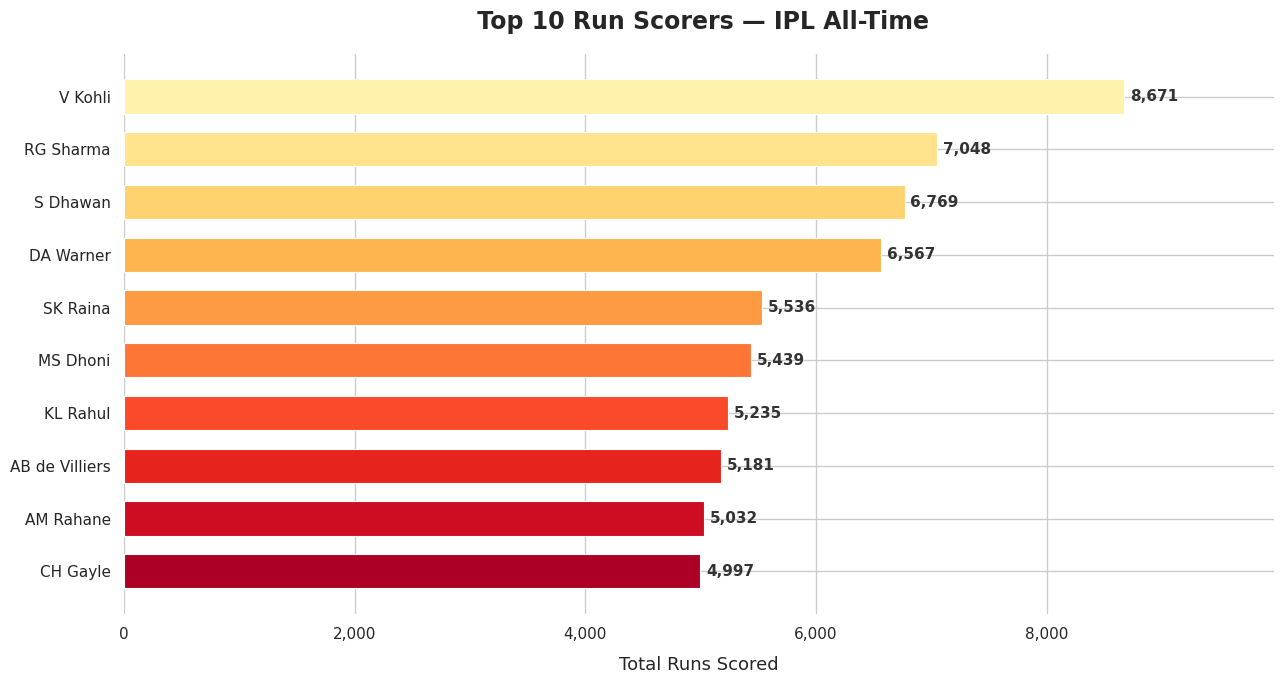

  Chart saved → ipl_charts/insight1_top_scorers.png



In [9]:
# STEP 7 — VISUALISATION 1 : TOP 10 RUN SCORERS
print("STEP 7 — Visualising Insight 1: Top 10 Run Scorers...")

fig, ax = plt.subplots(figsize=(13, 7))

# Colour gradient — lightest for lowest, darkest for highest scorer
colors = sns.color_palette("YlOrRd", n_colors=10)[::-1]

bars = ax.barh(
    y      = top_scorers['Batter'][::-1],       # Reverse so #1 sits at the top
    width  = top_scorers['Total_Runs'][::-1],
    color  = colors,
    height = 0.65,
    edgecolor = 'white',
    linewidth = 0.8
)

# Add value labels at the end of each bar
for bar in bars:
    ax.text(
        bar.get_width() + 50,                   # Slightly right of the bar end
        bar.get_y() + bar.get_height() / 2,     # Vertically centred
        f"{int(bar.get_width()):,}",            # Formatted: 7,200
        va='center', ha='left',
        fontweight='bold', fontsize=11, color='#333333'
    )

ax.set_xlabel('Total Runs Scored', fontsize=13, labelpad=10)
ax.set_title(' Top 10 Run Scorers — IPL All-Time',
             fontsize=17, fontweight='bold', pad=18)
ax.set_xlim(0, top_scorers['Total_Runs'].max() * 1.15)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig('ipl_charts/insight1_top_scorers.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Chart saved → ipl_charts/insight1_top_scorers.png")
print()

STEP 8 — Visualising Insight 2: Top 10 Wicket Takers...


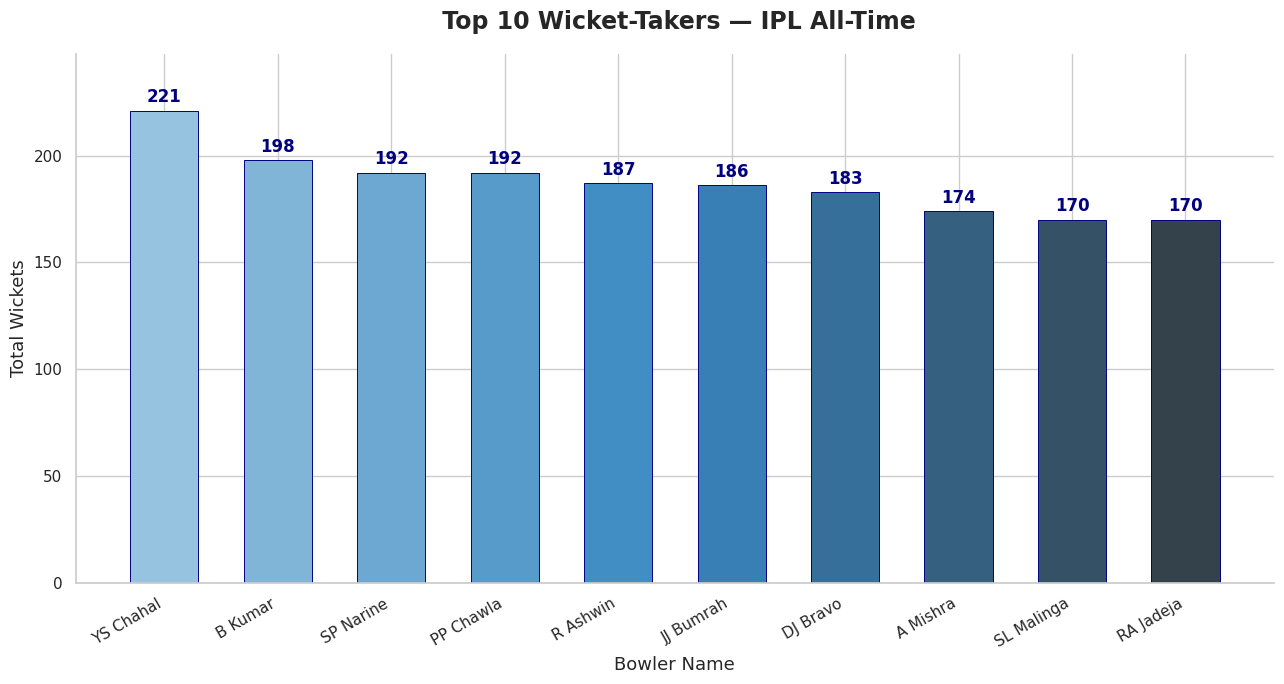

 Chart saved → ipl_charts/insight2_top_bowlers.png



In [10]:
# STEP 8 — VISUALISATION 2 : TOP 10 WICKET TAKERS
print("STEP 8 — Visualising Insight 2: Top 10 Wicket Takers...")

fig, ax = plt.subplots(figsize=(13, 7))

palette = sns.color_palette('Blues_d', n_colors=10)
bars = ax.bar(
    top_bowlers['Bowler'],
    top_bowlers['Wickets'],
    color     = palette,
    edgecolor = 'navy',
    linewidth = 0.7,
    width     = 0.6
)

# Value labels on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(int(bar.get_height())),
        ha='center', va='bottom',
        fontweight='bold', fontsize=12, color='navy'
    )

ax.set_xlabel('Bowler Name', fontsize=13)
ax.set_ylabel('Total Wickets', fontsize=13)
ax.set_title(' Top 10 Wicket-Takers — IPL All-Time',
             fontsize=17, fontweight='bold', pad=18)
ax.set_ylim(0, top_bowlers['Wickets'].max() * 1.12)
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()

plt.savefig('ipl_charts/insight2_top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Chart saved → ipl_charts/insight2_top_bowlers.png")
print()

STEP 9 — Visualising Insight 3: Toss vs Match Result...


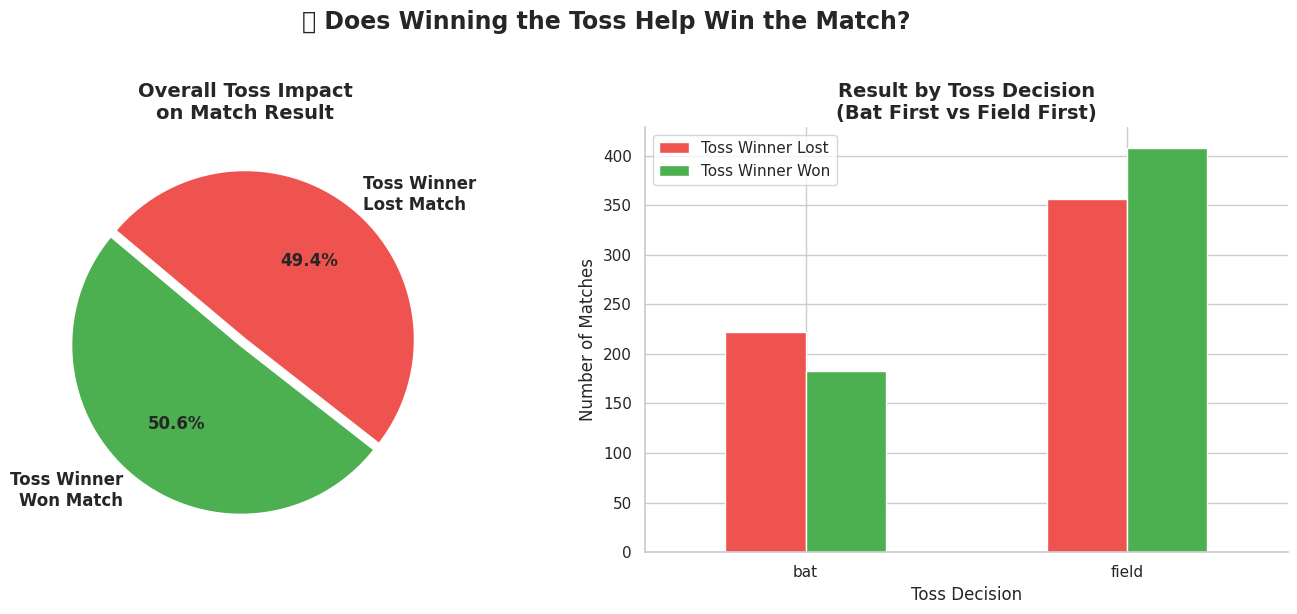

  Chart saved → ipl_charts/insight3_toss_impact.png



In [11]:
# STEP 9 — VISUALISATION 3 : TOSS vs MATCH RESULT
print("STEP 9 — Visualising Insight 3: Toss vs Match Result...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT — Pie chart
pie_labels = ['Toss Winner\nWon Match', 'Toss Winner\nLost Match']
pie_sizes  = [result_counts.get(True, 0), result_counts.get(False, 0)]
pie_colors = ['#4CAF50', '#EF5350']

wedges, texts, autotexts = axes[0].pie(
    pie_sizes,
    labels     = pie_labels,
    autopct    = '%1.1f%%',
    colors     = pie_colors,
    explode    = (0.04, 0),
    startangle = 140,
    textprops  = {'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops = {'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Toss Impact\non Match Result',
                  fontsize=14, fontweight='bold')

# RIGHT — Grouped bar: field vs bat decision
decision_breakdown = (
    toss_data
    .groupby(['toss_decision', 'toss_won_match'])
    .size()
    .unstack(fill_value=0)
)
decision_breakdown.columns = ['Toss Winner Lost', 'Toss Winner Won']
decision_breakdown.plot(
    kind      = 'bar',
    ax        = axes[1],
    color     = ['#EF5350', '#4CAF50'],
    edgecolor = 'white',
    width     = 0.5,
    rot       = 0
)
axes[1].set_title('Result by Toss Decision\n(Bat First vs Field First)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Toss Decision', fontsize=12)
axes[1].set_ylabel('Number of Matches', fontsize=12)
axes[1].legend(fontsize=11)
sns.despine(ax=axes[1])

plt.suptitle('🪙 Does Winning the Toss Help Win the Match?',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ipl_charts/insight3_toss_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Chart saved → ipl_charts/insight3_toss_impact.png")
print()

STEP 10 — Visualising Bonus 1: Season-wise Run Trend...


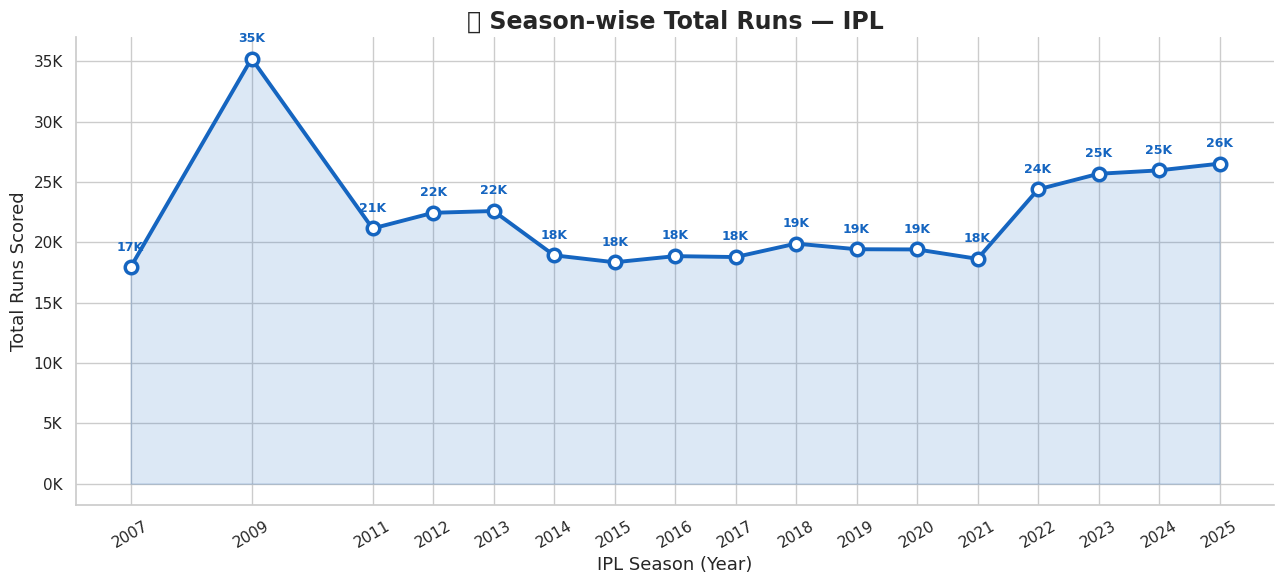

 Chart saved → ipl_charts/bonus1_season_trend.png



In [12]:
# STEP 10 — VISUALISATION BONUS 1 : SEASON-WISE RUN TREND
print("STEP 10 — Visualising Bonus 1: Season-wise Run Trend...")

season_runs['Season'] = season_runs['Season'].astype(int)
season_runs = season_runs.sort_values('Season')

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    season_runs['Season'], season_runs['Total_Runs'],
    color='#1565C0', linewidth=2.8, marker='o',
    markersize=9, markerfacecolor='white', markeredgewidth=2.5
)
ax.fill_between(season_runs['Season'], season_runs['Total_Runs'],
                alpha=0.15, color='#1565C0')

# Annotate each point with abbreviated value (e.g., 240K)
for _, row in season_runs.iterrows():
    ax.annotate(
        f"{int(row['Total_Runs']/1000)}K",
        (row['Season'], row['Total_Runs']),
        textcoords='offset points', xytext=(0, 12),
        ha='center', fontsize=9, fontweight='bold', color='#1565C0'
    )

ax.set_xlabel('IPL Season (Year)', fontsize=13)
ax.set_ylabel('Total Runs Scored', fontsize=13)
ax.set_title('📅 Season-wise Total Runs — IPL', fontsize=17, fontweight='bold')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K')
)
ax.set_xticks(season_runs['Season'])
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()

plt.savefig('ipl_charts/bonus1_season_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Chart saved → ipl_charts/bonus1_season_trend.png")
print()

STEP 11 — Visualising Bonus 2: Over-wise Scoring Pattern...


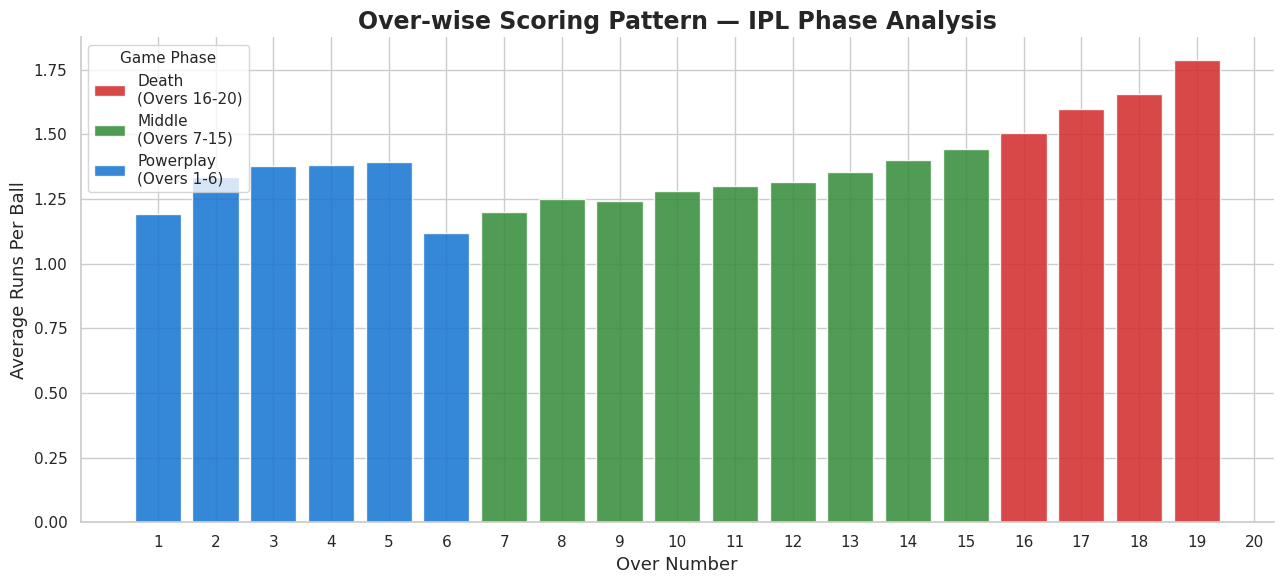

  Chart saved → ipl_charts/bonus2_over_pattern.png



In [13]:
# STEP 11 — VISUALISATION BONUS 2 : OVER-WISE SCORING PATTERN
print("STEP 11 — Visualising Bonus 2: Over-wise Scoring Pattern...")


def get_phase(over):
    """Assign a game phase label based on over number."""
    if over <= 6:   return 'Powerplay\n(Overs 1-6)'
    elif over <= 15: return 'Middle\n(Overs 7-15)'
    else:           return 'Death\n(Overs 16-20)'


over_avg['Over_Number'] = pd.to_numeric(over_avg['Over_Number'], errors='coerce')
over_avg['Phase']       = over_avg['Over_Number'].apply(get_phase)

phase_colors = {
    'Powerplay\n(Overs 1-6)' : '#1976D2',
    'Middle\n(Overs 7-15)'   : '#388E3C',
    'Death\n(Overs 16-20)'   : '#D32F2F'
}

fig, ax = plt.subplots(figsize=(13, 6))
for phase, grp in over_avg.groupby('Phase'):
    ax.bar(
        grp['Over_Number'],
        grp['Avg_Runs_Per_Ball'],
        color     = phase_colors[phase],
        label     = phase,
        alpha     = 0.88,
        edgecolor = 'white',
        width     = 0.8
    )

ax.set_xlabel('Over Number', fontsize=13)
ax.set_ylabel('Average Runs Per Ball', fontsize=13)
ax.set_title('Over-wise Scoring Pattern — IPL Phase Analysis',
             fontsize=17, fontweight='bold')
ax.legend(title='Game Phase', fontsize=11, title_fontsize=11)
ax.set_xticks(range(1, 21))
sns.despine()
plt.tight_layout()

plt.savefig('ipl_charts/bonus2_over_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Chart saved → ipl_charts/bonus2_over_pattern.png")
print()

STEP 11 — Visualising Bonus 2: Over-wise Scoring Pattern...


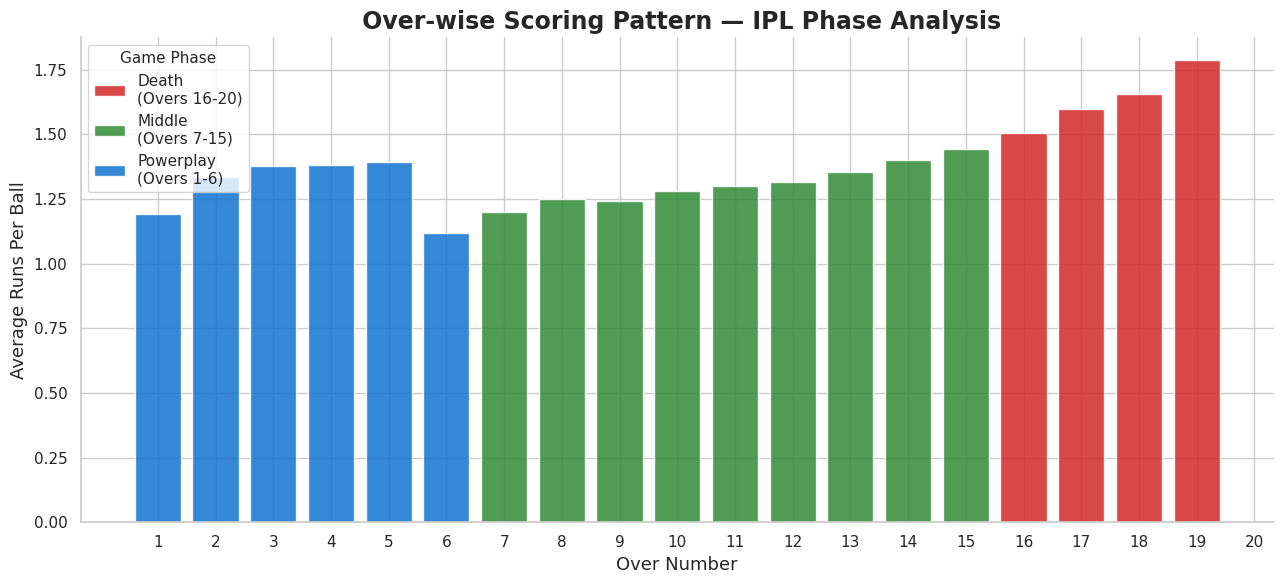

  Chart saved → ipl_charts/bonus2_over_pattern.png

STEP 12 — Exporting clean data files...
  ipl_clean.csv            (278,205 rows)
 ipl_batters_summary.csv  (703 batters)
  ipl_bowlers_summary.csv  (466 bowlers)
   ipl_matches_summary.csv  (1169 matches)
 ipl_season_summary.csv   (17 seasons)

   ALL DONE — IPL Analysis Complete!
  Charts saved in : ipl_charts/
  CSVs ready for  : Power BI / Tableau


In [14]:
# STEP 11 — VISUALISATION BONUS 2 : OVER-WISE SCORING PATTERN
print("STEP 11 — Visualising Bonus 2: Over-wise Scoring Pattern...")


def get_phase(over):
    """Assign a game phase label based on over number."""
    if over <= 6:   return 'Powerplay\n(Overs 1-6)'
    elif over <= 15: return 'Middle\n(Overs 7-15)'
    else:           return 'Death\n(Overs 16-20)'


over_avg['Over_Number'] = pd.to_numeric(over_avg['Over_Number'], errors='coerce')
over_avg['Phase']       = over_avg['Over_Number'].apply(get_phase)

phase_colors = {
    'Powerplay\n(Overs 1-6)' : '#1976D2',
    'Middle\n(Overs 7-15)'   : '#388E3C',
    'Death\n(Overs 16-20)'   : '#D32F2F'
}

fig, ax = plt.subplots(figsize=(13, 6))
for phase, grp in over_avg.groupby('Phase'):
    ax.bar(
        grp['Over_Number'],
        grp['Avg_Runs_Per_Ball'],
        color     = phase_colors[phase],
        label     = phase,
        alpha     = 0.88,
        edgecolor = 'white',
        width     = 0.8
    )

ax.set_xlabel('Over Number', fontsize=13)
ax.set_ylabel('Average Runs Per Ball', fontsize=13)
ax.set_title(' Over-wise Scoring Pattern — IPL Phase Analysis',
             fontsize=17, fontweight='bold')
ax.legend(title='Game Phase', fontsize=11, title_fontsize=11)
ax.set_xticks(range(1, 21))
sns.despine()
plt.tight_layout()

plt.savefig('ipl_charts/bonus2_over_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Chart saved → ipl_charts/bonus2_over_pattern.png")
print()

# STEP 12 — EXPORT CLEAN DATA FOR POWER BI / TABLEAU
print("STEP 12 — Exporting clean data files...")

# Full clean dataset
df_clean.to_csv('ipl_clean.csv', index=False)
print(f"  ipl_clean.csv            ({df_clean.shape[0]:,} rows)")

# Batters summary — useful for Power BI card visuals
batters_summary = (
    df_clean.groupby('batter')
    .agg(
        total_runs   = ('runs_batter', 'sum'),
        total_balls  = ('balls_faced', 'sum'),
        matches      = ('match_id', 'nunique')
    )
    .reset_index()
    .sort_values('total_runs', ascending=False)
)
batters_summary['strike_rate'] = (
    batters_summary['total_runs'] / batters_summary['total_balls'].replace(0, np.nan) * 100
).round(2)
batters_summary.to_csv('ipl_batters_summary.csv', index=False)
print(f" ipl_batters_summary.csv  ({len(batters_summary)} batters)")

# Bowlers summary
excluded = ['None', 'run out', 'retired hurt', 'obstructing the field']
bowlers_summary = (
    df_clean[~df_clean['wicket_kind'].isin(excluded)]
    .groupby('bowler')['wicket_kind']
    .count()
    .reset_index()
    .rename(columns={'wicket_kind': 'wickets'})
    .sort_values('wickets', ascending=False)
)
bowlers_summary.to_csv('ipl_bowlers_summary.csv', index=False)
print(f"  ipl_bowlers_summary.csv  ({len(bowlers_summary)} bowlers)")

# Match-level summary
matches_summary = df_clean.drop_duplicates('match_id')[[
    'match_id', 'date', 'season_year', 'batting_team', 'bowling_team',
    'toss_winner', 'toss_decision', 'match_won_by', 'venue', 'city'
]].dropna(subset=['match_won_by'])
matches_summary.to_csv('ipl_matches_summary.csv', index=False)
print(f"   ipl_matches_summary.csv  ({len(matches_summary)} matches)")

# Season summary
season_summary = (
    df_clean.groupby('season_year')
    .agg(
        total_runs   = ('runs_total', 'sum'),
        total_matches= ('match_id', 'nunique'),
        total_balls  = ('ball_no', 'count')
    )
    .reset_index()
    .rename(columns={'season_year': 'season'})
)
season_summary.to_csv('ipl_season_summary.csv', index=False)
print(f" ipl_season_summary.csv   ({len(season_summary)} seasons)")

print()
print("=" * 60)
print("   ALL DONE — IPL Analysis Complete!")
print("  Charts saved in : ipl_charts/")
print("  CSVs ready for  : Power BI / Tableau")
print("=" * 60)

conn.close()